# PGA Tour Expected Strokes - Off-the-Tee

The [Shotlink System](https://shotlink.com/about/history) provides detailed shot-by-shot location data for PGA Tour events, and these data led to many groundbreaking advances in golf analytics. The [strokes gained](http://www.columbia.edu/~mnb2/broadie/Assets/broadie_wscg_v_200804.pdf) metric, a measure of how a golfer's shots compare to an expectation given ball location and other information, headlines these advances.

This notebook contains an effort to replicate the tee shot portion of strokes gained. That is, given the distance of the tee from the hole, what is the expected number of strokes needed to hole out?

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import pickle

from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
hole_df = pd.read_csv("/content/drive/MyDrive/Golf/drive.csv")
hole_df

,event_id,year,player_id,round_num,hole,strokes,hole_number,par,distance
0,R2021464,2021,1810,1,1,3,1,4,436
1,R2021464,2021,10809,1,1,4,1,4,436
2,R2021464,2021,12510,1,1,5,1,4,436
3,R2021464,2021,12716,1,1,4,1,4,436
4,R2021464,2021,19803,1,1,5,1,4,436
...,...,...,...,...,...,...,...,...,...
192936,R2022541,2022,52375,4,18,4,18,4,512
192937,R2022541,2022,52666,4,18,4,18,4,512
192938,R2022541,2022,52686,4,18,5,18,4,512
192939,R2022541,2022,55182,4,18,5,18,4,512


These data have been filtered and aggregated from the shot-by-shot data. Data cleaning included

*   Removing shots with missing or zero distance from the hole
*   Ensuring each event-year-golfer-round-hole has a tee shot and hole out (that is, each hole started ended in a hole out)
*   Removing provisional shots

With observations at the golfer-hole level, taking the mean strokes across each hole allows models to be fit at the hole level and observations can be weighted by the number of golfers to play the hole.

However, since this will be used downstream in a simulation framework, we need more than just expected strokes. Knowing the probability that a player will finish a hole in any given number of strokes will fit nicely within a simulation, so the following leverages [ordered logistic regression](https://www.statsmodels.org/devel/generated/statsmodels.miscmodels.ordinal_model.OrderedModel.html) to approximate the distribution of expected strokes.

In [3]:
avg_df = pd.DataFrame(hole_df.groupby(["event_id", "year", "round_num", "hole"])[["strokes", "par", "distance"]].mean()).reset_index()
count_df = pd.DataFrame(hole_df.groupby(["event_id", "year", "round_num", "hole"])["strokes"].count()).reset_index()

count_df.columns = ["event_id", "year", "round_num", "hole", "count"]
avg_df = avg_df.merge(count_df, on=["event_id", "year", "round_num", "hole",])
avg_df[(avg_df["event_id"]=="R2021464") & (avg_df["round_num"]==1) & (avg_df["hole"]==1)]

,event_id,year,round_num,hole,strokes,par,distance,count
288,R2021464,2021,1,1,3.907285,4.0,436.0,151


As an example for the first approach, here is the first hole in the first round of the RSM Classic in 2021. The par-4 played about a tenth of a stroke easier across 151 golfers.

## Modeling

Broadie cites that a piecewise polynomial fit to hole distance performs better than a simple linear regression. Indeed, Figure 1 from his paper seems to indicate as much.

With varying intercepts and slopes being apparent, fitting separate models by hole type would likely be sufficient. Such a modeling framework would leave some information sharing between hole types, which might be helpful for par-4 and par-5 holes especially. But, given sufficient sample size across each hole type, the benefit of any information sharing is likely minor. With that, let's fit an expected strokes model for each set of par-3, par-4, and par-5 holes, and begin by splitting the dataset.

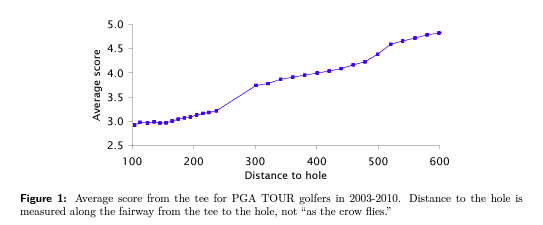

In [4]:
x_train, x_test, y_train, y_test = train_test_split(hole_df[["par", "distance"]], hole_df[["strokes"]], test_size=0.25, random_state=42)

### Par-3 Holes

In [5]:
par_3_df = hole_df[hole_df["par"]==3]
x_train3, x_test3, y_train3, y_test3 = train_test_split(par_3_df[["distance"]], par_3_df[["strokes"]], test_size=0.25, random_state=42)
mod_prob = OrderedModel(
    y_train3["strokes"], x_train3[["distance"]], distr="logit"
)

res_prob = mod_prob.fit(method="bfgs")
res_prob.summary()

Optimization terminated successfully.
         Current function value: 0.952850
         Iterations: 43
         Function evaluations: 47
         Gradient evaluations: 47


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                strokes   Log-Likelihood:                -32087.
Model:                   OrderedModel   AIC:                         6.419e+04
Method:            Maximum Likelihood   BIC:                         6.428e+04
Date:                Wed, 23 Sep 2026                                         
Time:                        18:48:18                                         
No. Observations:               33675                                         
Df Residuals:                   33665                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
distance       0.0017      0.000      3.701      0.000       0.001       0.003
1/2           -7.6838      0.315    -24.369      0.000      -8.302      -7.066
2/3            1.8053      0.050     36.457      0.000       1.708       1.902
3/4            1.1982      0.006    206.333      0.000       1.187       1.210
4/5            0.7505      0.014     52.651      0.000       0.723       0.778
5/6            0.6401      0.039     16.306      0.000       0.563       0.717
6/7            0.5998      0.101      5.965      0.000       0.403       0.797
7/8            0.6060      0.250      2.424      0.015       0.116       1.096
8/9           -0.3664      0.721     -0.508      0.611      -1.780       1.047
9/13          -0.3665      1.019     -0.360      0.719      -2.363       1.630
==============================================================================
"""

Here, since the model predicts the probability of finishing the hole for any given number of strokes present in the dataset, we need to take the dot product of those probabilities and the number of strokes to get a predicted expected strokes value.

Also, note above that the final cut in the above model is between 9 strokes and 13 strokes, meaning that there are no examples of golfers finishing a par-3 in 10, 11, or 12 strokes. Given the low likelihood of all of those outcomes for professional golfers, the dot product simply ignores this nuance without losing much.

In [6]:
preds = res_prob.predict(x_train3[["distance"]])
strokes = np.array(range(1, len(preds.columns)+1))
preds_strokes = np.dot(preds.values, strokes)
preds_strokes

array([3.11299293, 3.12694575, 3.11459785, ..., 3.11513311, 3.12103051,
       3.11673975])

In [7]:
test_preds = res_prob.predict(x_test3[["distance"]])
test_strokes = np.array(range(1, len(test_preds.columns)+1))
test_preds_strokes = np.dot(test_preds.values, test_strokes)

print("Training Set MAE: " + str(round(mean_absolute_error(y_train3["strokes"],
                                                           preds_strokes), 3)))
print("Test Set MAE: " + str(round(mean_absolute_error(y_test3["strokes"],
                                                       test_preds_strokes), 3)))

Training Set MAE: 0.431
Test Set MAE: 0.429


### Par-4 Holes

In [8]:
par_4_df = hole_df[hole_df["par"]==4]
x_train4, x_test4, y_train4, y_test4 = train_test_split(par_4_df[["distance"]], par_4_df[["strokes"]], test_size=0.25, random_state=42)
mod_prob4 = OrderedModel(
    y_train4["strokes"], x_train4[["distance"]], distr="logit"
)

res_prob4 = mod_prob4.fit(method="bfgs")
res_prob4.summary()

Optimization terminated successfully.
         Current function value: 0.980830
         Iterations: 106
         Function evaluations: 125
         Gradient evaluations: 125


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                strokes   Log-Likelihood:                -81086.
Model:                   OrderedModel   AIC:                         1.622e+05
Method:            Maximum Likelihood   BIC:                         1.623e+05
Date:                Wed, 23 Sep 2026                                         
Time:                        18:49:05                                         
No. Observations:               82671                                         
Df Residuals:                   82661                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
distance       0.0079      0.000     48.953      0.000       0.008       0.008
1/2           -7.9588      1.001     -7.947      0.000      -9.922      -5.996
2/3            1.7478      0.174     10.060      0.000       1.407       2.088
3/4            1.4244      0.014    104.746      0.000       1.398       1.451
4/5            1.1307      0.004    298.055      0.000       1.123       1.138
5/6            0.8383      0.010     83.078      0.000       0.819       0.858
6/7            0.7454      0.031     24.308      0.000       0.685       0.805
7/8            0.7042      0.087      8.087      0.000       0.534       0.875
8/9            0.5441      0.235      2.313      0.021       0.083       1.005
9/10          -0.6716      0.715     -0.940      0.347      -2.072       0.729
==============================================================================
"""

In [9]:
preds4 = res_prob4.predict(x_train4[["distance"]])
strokes4 = np.array(range(1, len(preds4.columns)+1))
preds_strokes4 = np.dot(preds4.values, strokes4)
preds_strokes4

array([3.98965437, 3.82928372, 3.89838314, ..., 4.15625119, 3.89345513,
       4.00204267])

In [10]:
test_preds4 = res_prob4.predict(x_test4[["distance"]])
test_strokes4 = np.array(range(1, len(test_preds4.columns)+1))
test_preds_strokes4 = np.dot(test_preds4.values, test_strokes4)

print("Training Set MAE: " + str(round(mean_absolute_error(y_train4["strokes"],
                                                           preds_strokes4), 3)))
print("Test Set MAE: " + str(round(mean_absolute_error(y_test4["strokes"],
                                                       test_preds_strokes4), 3)))

Training Set MAE: 0.434
Test Set MAE: 0.437


### Par-5 Holes

In [11]:
par_5_df = hole_df[hole_df["par"]==5]
x_train5, x_test5, y_train5, y_test5 = train_test_split(par_5_df[["distance"]], par_5_df[["strokes"]], test_size=0.25, random_state=42)
mod_prob5 = OrderedModel(
    y_train5["strokes"], x_train5[["distance"]], distr="logit"
)

res_prob5 = mod_prob5.fit(method="bfgs")
res_prob5.summary()

Optimization terminated successfully.
         Current function value: 1.101141
         Iterations: 83
         Function evaluations: 96
         Gradient evaluations: 96


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                strokes   Log-Likelihood:                -31227.
Model:                   OrderedModel   AIC:                         6.247e+04
Method:            Maximum Likelihood   BIC:                         6.255e+04
Date:                Wed, 23 Sep 2026                                         
Time:                        18:49:15                                         
No. Observations:               28359                                         
Df Residuals:                   28350                                         
Df Model:                           1                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
distance       0.0091      0.000     24.559      0.000       0.008       0.010
2/3           -2.7721      0.380     -7.301      0.000      -3.516      -2.028
3/4            1.5250      0.068     22.268      0.000       1.391       1.659
4/5            1.1631      0.010    113.359      0.000       1.143       1.183
5/6            0.9060      0.008    109.545      0.000       0.890       0.922
6/7            0.7124      0.023     30.397      0.000       0.666       0.758
7/8            0.4861      0.063      7.727      0.000       0.363       0.609
8/9            0.3376      0.142      2.375      0.018       0.059       0.616
9/10          -0.0010      0.301     -0.003      0.997      -0.591       0.589
==============================================================================
"""

In [12]:
preds5 = res_prob5.predict(x_train5[["distance"]])
strokes5 = np.array(range(2, len(preds5.columns)+2))
preds_strokes5 = np.dot(preds5.values, strokes5)
preds_strokes5

array([4.67285332, 4.71818904, 4.51580318, ..., 4.64513509, 4.55956292,
       4.51246074])

In [13]:
test_preds5 = res_prob5.predict(x_test5[["distance"]])
test_strokes5 = np.array(range(2, len(test_preds5.columns)+2))
test_preds_strokes5 = np.dot(test_preds5.values, test_strokes5)
test_preds_strokes5

print("Training Set MAE: " + str(round(mean_absolute_error(y_train5["strokes"],
                                                           preds_strokes5), 3)))
print("Test Set MAE: " + str(round(mean_absolute_error(y_test5["strokes"],
                                                       test_preds_strokes5), 3)))

Training Set MAE: 0.62
Test Set MAE: 0.624


### Model Visualization

Performance on the test set is comparable to that on the training set for each hole type, so let's examine the model fits to see if they each seem reasonable.

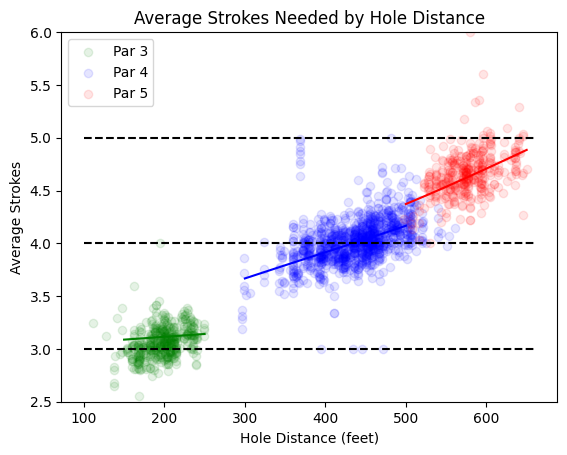

In [14]:
# Visualize test set observations
fig, ax = plt.subplots()
ax.scatter(avg_df[avg_df["par"]==3]["distance"], avg_df[avg_df["par"]==3]["strokes"],
           c="green", label="Par 3", alpha=0.1)
ax.scatter(avg_df[avg_df["par"]==4]["distance"], avg_df[avg_df["par"]==4]["strokes"],
           c="blue", label="Par 4", alpha=0.1)
ax.scatter(avg_df[avg_df["par"]==5]["distance"], avg_df[avg_df["par"]==5]["strokes"],
           c="red", label="Par 5", alpha=0.1)

# Visualize model predictions
## Par-3
dist = np.linspace(150, 250, 100)
test_df = pd.DataFrame({"distance": dist})
par_3_preds = res_prob.predict(test_df)
strokes3 = np.array(range(1, len(par_3_preds.columns)+1))
preds_strokes3 = np.dot(par_3_preds.values, strokes3)
ax.plot(dist, preds_strokes3, "g-")

# Par-4
dist = np.linspace(300, 500, 100)
test_df = pd.DataFrame({"distance": dist})
par_4_preds = res_prob4.predict(test_df)
strokes4 = np.array(range(1, len(par_4_preds.columns)+1))
preds_strokes4 = np.dot(par_4_preds.values, strokes4)
ax.plot(dist, preds_strokes4, "b-")

# Par-5
dist = np.linspace(500, 650, 100)
test_df = pd.DataFrame({"distance": dist})
par_5_preds = res_prob5.predict(test_df)
strokes5 = np.array(range(2, len(par_5_preds.columns)+2))
preds_strokes5 = np.dot(par_5_preds.values, strokes5)
ax.plot(dist, preds_strokes5, "r-")

# Add even-par indicators
plt.hlines(3, 100, 660, 'k', '--')
plt.hlines(4, 100, 660, 'k', '--')
plt.hlines(5, 100, 660, 'k', '--')
plt.ylim(2.5, 6)

plt.title("Average Strokes Needed by Hole Distance")
plt.ylabel("Average Strokes")
plt.xlabel("Hole Distance (feet)")

ax.legend()
plt.show()

The linear fits by hole type appear reasonable. Interestingly, the linear models predict most par-3 holes to play over par and most par-5 holes to play under par. Anecdotally, this seems to match intuition. Par-5 holes offer more chances to recover from mistakes or poor shots, while par-3 holes aren't as forgiving. This result seems to match Broadie's findings as well, so let's move forward with these at the moment.

In [ ]:
models = {
    "par_3": res_prob,
    "par_4": res_prob4,
    "par_5": res_prob5,
}
with open('/content/drive/MyDrive/Golf/drive_models.pkl', 'wb') as handle:
    pickle.dump(models, handle)